# Decadal Warming Trends with ERA5 (1940-2024)

This notebook demonstrates how to analyze long-term climate trends using the **ERA5 single-levels timeseries** dataset. We will focus on two key indicators of summer heat:

1.  **Summer Days (SU)**: Number of days in a year where the maximum temperature ($T_{max}$) exceeds 25°C.
2.  **Tropical Nights (TR)**: Number of days in a year where the minimum temperature ($T_{min}$) exceeds 20°C.

Using the entire ERA5 record (1940 to present) allows us to visualize the significant shift in these indicators over the decades.

> [!NOTE]
> This example uses the `reanalysis-era5-single-levels-timeseries` dataset, which is specifically optimized for efficient access to full time series at specific locations or small regions.

## 1. Setup and Location Selection

We import the necessary libraries and define our location of interest. For this demonstration, we'll use **Madrid, Spain**, a city that has experienced a clear increase in extreme heat events over the last century.

In [4]:
import earthkit.data as ekd
import earthkit.transforms as ekt
import matplotlib.pyplot as plt
import pandas as pd

from earthkit.climate.indicators import temperature

## 2. Data Acquisition (ERA5 Timeseries)

We retrieve the hourly 2m temperature data from 1940 to 2024. The `timeseries` dataset is ideal for this purpose as it minimizes the overhead of downloading large global fields when we only need specific coordinates.

In [5]:
MADRID_COORD = [40.41, -3.70]
location = {"latitude": MADRID_COORD[0], "longitude": MADRID_COORD[1]}

print("Requesting data from CDS... This may take a few minutes as we are fetching 80+ years of data.")

data = ekd.from_source(
    "cds",
    "reanalysis-era5-single-levels-timeseries",
    request={
        "variable": "2m_temperature",
        "date": "1940-01-01/2025-12-31",
        "location": location,
        "data_format": "netcdf",
    },
)

print("Data loaded successfully.")

Requesting data from CDS... This may take a few minutes as we are fetching 80+ years of data.


2026-04-08 11:59:10,503 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
INFO:ecmwf.datastores.legacy_client:[2026-02-16T00:00:00] - To generate this ERA5 hourly time series datase

Data loaded successfully.


## 3. Processing: Daily Extremes

Climate indices like Summer Days and Tropical Nights are typically calculated from daily maximum and minimum temperatures. We resample our hourly ERA5 data to obtain these daily values.

In [6]:
# Convert GRIB to Xarray and rename to standard CF name 'tas' (temperature at surface)
ds = data.to_xarray().rename({"t2m": "tas", "valid_time": "time"})

# Ensure units are correct (K is standard in GRIB)
ds["tas"].attrs.update({"units": "K", "standard_name": "air_temperature"})

# Calculate Daily Maximum (Tmax) and Minimum (Tmin)
tmax_daily = ekt.temporal.daily_reduce(ds["tas"], how="max")
tmin_daily = ekt.temporal.daily_reduce(ds["tas"], how="min")

# Re-apply attributes needed by climate indicators
tmin_daily.attrs["units"] = "K"
tmin_daily.attrs["standard_name"] = "air_temperature"
tmin_daily.attrs["cell_methods"] = "time: minimum"

tmax_daily.attrs["units"] = "K"
tmax_daily.attrs["standard_name"] = "air_temperature"
tmax_daily.attrs["cell_methods"] = "time: maximum"

## 4. Computing Climate Indicators

Now we use `earthkit-climate` to compute the annual count of Summer Days and Tropical Nights. These indicators are automatically sensitive to the temperature units and thresholds.

In [7]:
# Summer Days: Tmax > 25°C (298.15 K)
su_annual = temperature.tx_days_above(tmax_daily, thresh="25 degC").squeeze()

# Tropical Nights: Tmin > 20°C (293.15 K)
tr_annual = temperature.tn_days_above(tmin_daily, thresh="20 degC").squeeze()

## 5. Visualizing the Decadal Trend

To better understand how these indicators have evolved, we will plot the annual values and then calculate the average per decade. Decadal averaging smooths out interannual variability (like El Niño events) and reveals the underlying climate signal.

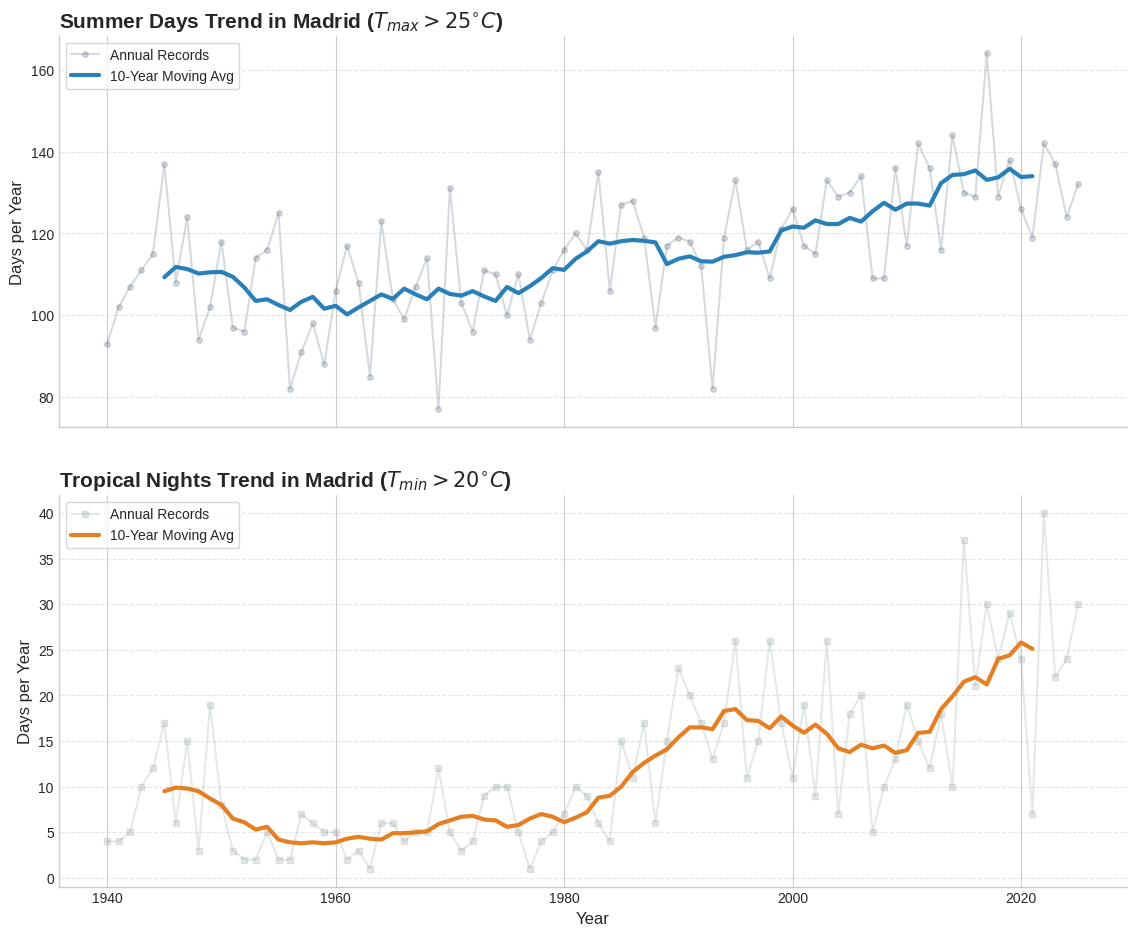

In [8]:
# Data preparation
df = pd.DataFrame(
    {"Summer Days": su_annual.values, "Tropical Nights": tr_annual.values}, index=su_annual.time.dt.year.values
)

# Calculate 10-year rolling averages for trend visualization
df_smooth = df.rolling(window=10, center=True).mean()

# Plotting configuration
plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, dpi=100)

# --- Subplot 1: Summer Days ---
# Raw data in the background
ax1.plot(
    df.index,
    df["Summer Days"],
    marker="o",
    markersize=4,
    linestyle="-",
    color="#34495e",
    alpha=0.2,
    label="Annual Records",
)
# Trend line in the foreground
ax1.plot(df_smooth.index, df_smooth["Summer Days"], color="#2980b9", linewidth=3, label="10-Year Moving Avg")

ax1.set_title(r"Summer Days Trend in Madrid ($T_{max} > 25^{\circ}C$)", fontsize=15, fontweight="bold", loc="left")
ax1.set_ylabel("Days per Year", fontsize=12)
ax1.legend(loc="upper left", frameon=True)

# --- Subplot 2: Tropical Nights ---
# Raw data in the background
ax2.plot(
    df.index,
    df["Tropical Nights"],
    marker="s",
    markersize=4,
    linestyle="-",
    color="#7f8c8d",
    alpha=0.2,
    label="Annual Records",
)
# Trend line in the foreground
ax2.plot(df_smooth.index, df_smooth["Tropical Nights"], color="#e67e22", linewidth=3, label="10-Year Moving Avg")

ax2.set_title(r"Tropical Nights Trend in Madrid ($T_{min} > 20^{\circ}C$)", fontsize=15, fontweight="bold", loc="left")
ax2.set_ylabel("Days per Year", fontsize=12)
ax2.set_xlabel("Year", fontsize=12)
ax2.legend(loc="upper left", frameon=True)

# Final Polish
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(labelsize=10)

plt.tight_layout(pad=3.0)
plt.show()

### Decadal Averages Comparison

We now compare the decadal averages to see the long-term progression.

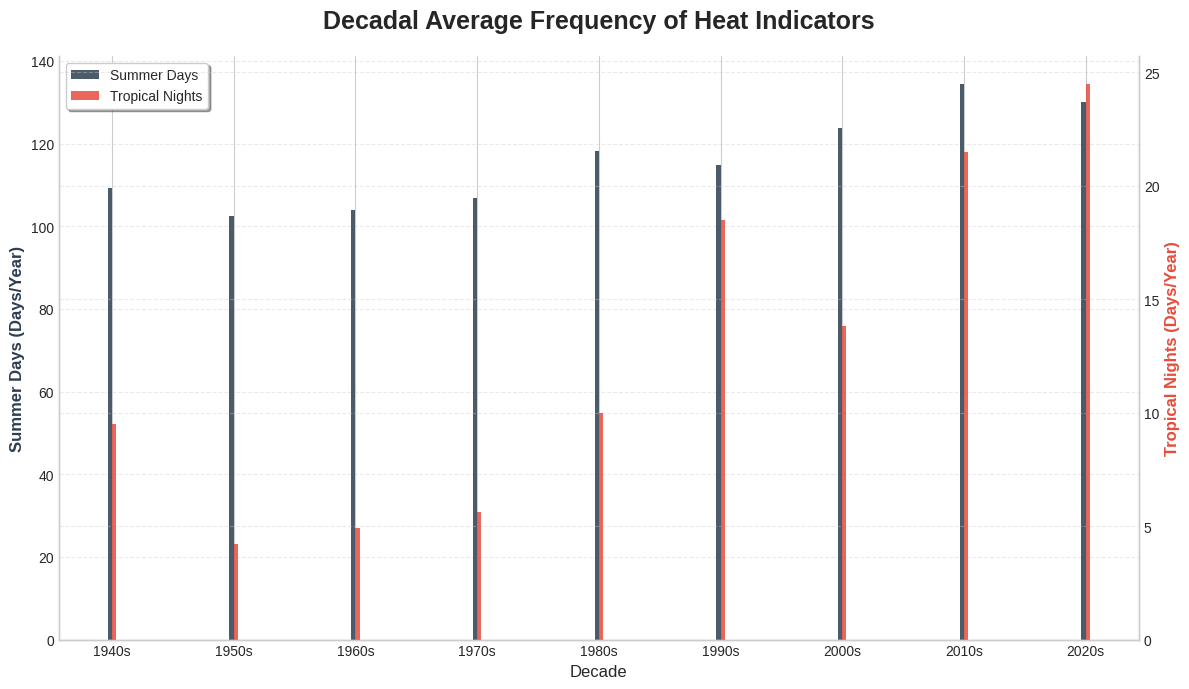

In [9]:
# Calculate decadal averages
df_decadal = df.groupby(df.index // 10 * 10).mean()

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 7))

width = 0.35
indices = df_decadal.index

# First Variable (Left Axis)
bar1 = ax1.bar(
    indices - width / 2, df_decadal.iloc[:, 0], width, label=df_decadal.columns[0], color="#2c3e50", alpha=0.85
)

# Second Axis
ax2 = ax1.twinx()

# Second Variable (Right Axis)
bar2 = ax2.bar(
    indices + width / 2, df_decadal.iloc[:, 1], width, label=df_decadal.columns[1], color="#e74c3c", alpha=0.85
)

# Styling and Labels
ax1.set_title("Decadal Average Frequency of Heat Indicators", fontsize=18, pad=20, fontweight="bold")
ax1.set_xlabel("Decade", fontsize=12)
ax1.set_ylabel(f"{df_decadal.columns[0]} (Days/Year)", fontsize=12, color="#2c3e50", fontweight="bold")
ax2.set_ylabel(f"{df_decadal.columns[1]} (Days/Year)", fontsize=12, color="#e74c3c", fontweight="bold")

# Formatting X-axis for decades (e.g., 1990s)
ax1.set_xticks(indices)
ax1.set_xticklabels([f"{int(x)}s" for x in indices], rotation=0)

# Unified Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=True, shadow=True)

# Spines and Grid
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Summary

As we can see from the decadal plots, there is a clear upward trend in both Summer Days and Tropical Nights since the 1940s. While Summer Days have increased, the rise in Tropical Nights is often even more pronounced in urban areas like Madrid, reflecting the combined impact of global warming and the urban heat island effect.

Using ERA5's full time series provides the necessary historical context to identify these long-term climate shifts.